In [ ]:
!pip install -q tensorflow gradio scikit-learn seaborn

In [ ]:
!pip install kaggle

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input
)

from tensorflow.keras.models import Model

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:04<00:00, 167MB/s]



In [ ]:
!unzip -q "/content/plantdisease.zip" -d "/content/dataset"

In [ ]:
dataset_path = "/content/dataset/PlantVillage"

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(class_names)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
import os
for cls in os.listdir(dataset_path):
    p = os.path.join(dataset_path,cls)

    if os.path.isdir(p):
        print(cls, len(os.listdir(p)))

Tomato_Spider_mites_Two_spotted_spider_mite 1676
Tomato__Tomato_mosaic_virus 373
Tomato_healthy 1591
Potato___Late_blight 1000
Tomato_Leaf_Mold 952
Tomato_Septoria_leaf_spot 1771
Tomato__Tomato_YellowLeaf__Curl_Virus 3209
Potato___healthy 152
Potato___Early_blight 1000
Pepper__bell___Bacterial_spot 997
Tomato_Late_blight 1909
Tomato_Bacterial_spot 2127
Pepper__bell___healthy 1478
Tomato_Early_blight 1000
Tomato__Target_Spot 1404


In [ ]:
class_names = train_ds.class_names

print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(
        0.1,
        0.1
    )
])

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

outputs = Dense(
    len(class_names),
    activation='softmax'
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 15)        │     30,735 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,618,447 (90.10 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 100s 169ms/step - accuracy: 0.7356 - loss: 0.8450 - val_accuracy: 0.8369 - val_loss: 0.4814
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 87s 169ms/step - accuracy: 0.8634 - loss: 0.4259 - val_accuracy: 0.8597 - val_loss: 0.4007
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 88s 171ms/step - accuracy: 0.8836 - loss: 0.3549 - val_accuracy: 0.8447 - val_loss: 0.4521
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 142s 170ms/step - accuracy: 0.8924 - loss: 0.3292 - val_accuracy: 0.8767 - val_loss: 0.3519
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 89s 172ms/step - accuracy: 0.8966 - loss: 0.3106 - val_accuracy: 0.8755 - val_loss: 0.3524
Epoch 6/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 90s 175ms/step - accuracy: 0.8994 - loss: 0.2964 - val_accuracy: 0.9060 - val_loss: 0.2607
Epoch 7/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 90s 174ms/step - accuracy: 0.9024 - loss: 0.2875 - val_accuracy: 0.8968 - val_loss: 0.3012
Epoch 8/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 89s 173ms/step - accuracy: 0.9049 - loss:

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 132s 230ms/step - accuracy: 0.8565 - loss: 0.5044 - val_accuracy: 0.8919 - val_loss: 0.3656
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9198 - loss: 0.2413 - val_accuracy: 0.9024 - val_loss: 0.3047
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 123s 238ms/step - accuracy: 0.9371 - loss: 0.1829 - val_accuracy: 0.9220 - val_loss: 0.2380
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 137s 229ms/step - accuracy: 0.9506 - loss: 0.1481 - val_accuracy: 0.9251 - val_loss: 0.2346
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 119s 230ms/step - accuracy: 0.9534 - loss: 0.1363 - val_accuracy: 0.9414 - val_loss: 0.1704
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 140s 226ms/step - accuracy: 0.9626 - loss: 0.1125 - val_accuracy: 0.9404 - val_loss: 0.1719
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 144s 230ms/step - accuracy: 0.9655 - loss: 0.1002 - val_accuracy: 0.9431 - val_loss: 0.1653
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - accuracy: 0.9687 -

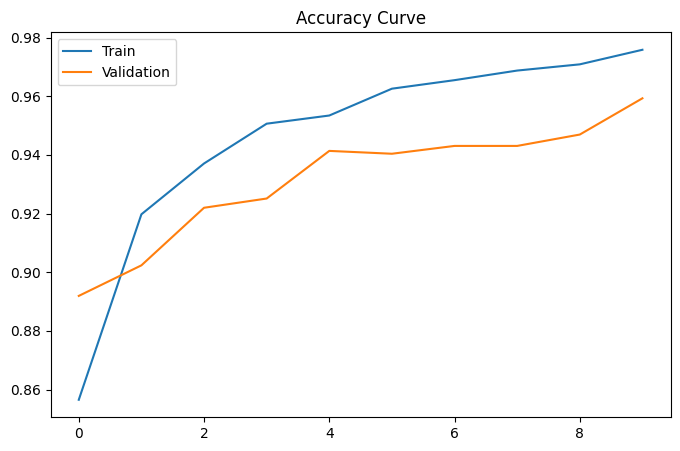

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])

plt.legend([
    'Train',
    'Validation'
])

plt.title("Accuracy Curve")

plt.show()

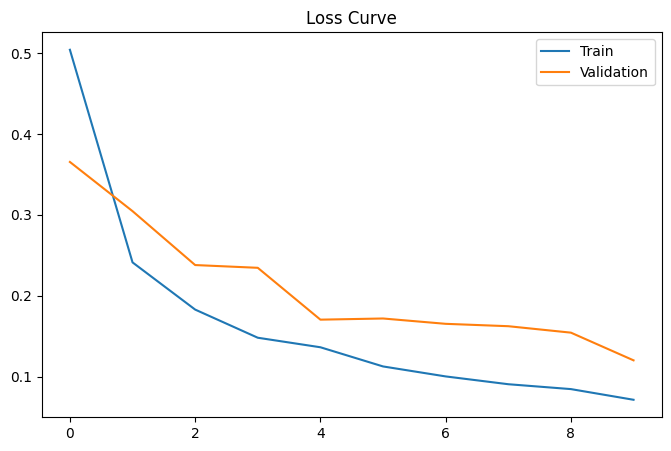

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_fine.history['loss'])
plt.plot(history_fine.history['val_loss'])

plt.legend([
    'Train',
    'Validation'
])

plt.title("Loss Curve")

plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:

    pred = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(pred,axis=1)
    )

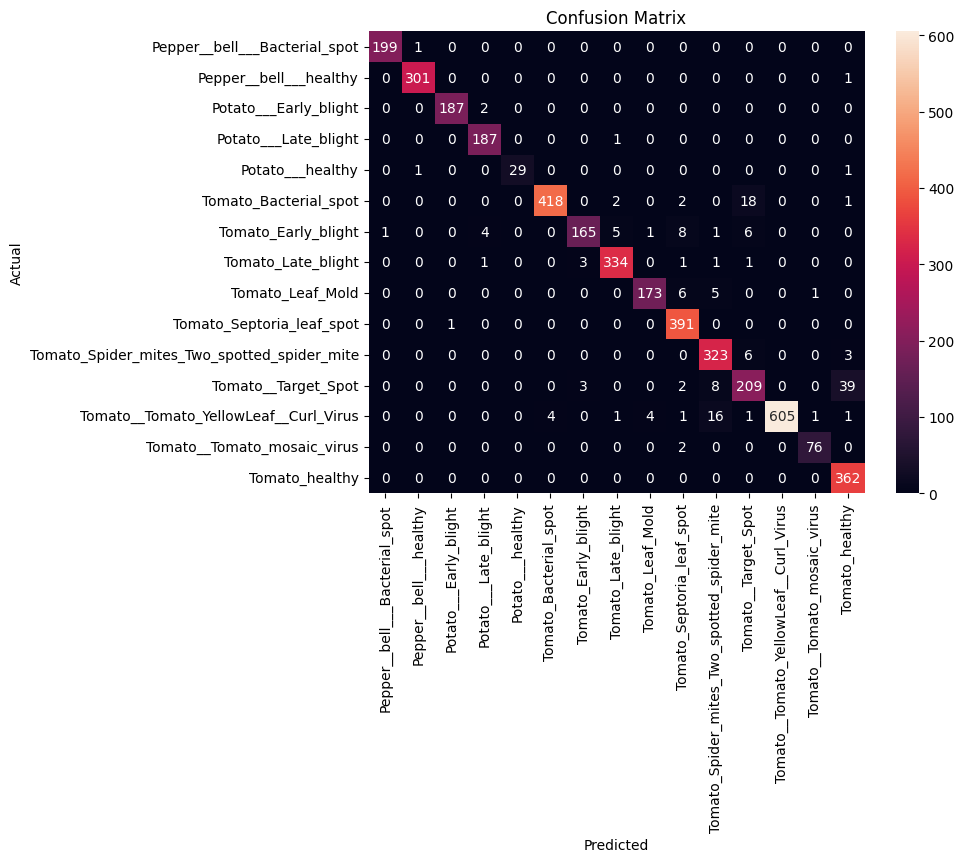

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.99      0.99       200
                     Pepper__bell___healthy       0.99      1.00      1.00       302
                      Potato___Early_blight       0.99      0.99      0.99       189
                       Potato___Late_blight       0.96      0.99      0.98       188
                           Potato___healthy       1.00      0.94      0.97        31
                      Tomato_Bacterial_spot       0.99      0.95      0.97       441
                        Tomato_Early_blight       0.96      0.86      0.91       191
                         Tomato_Late_blight       0.97      0.98      0.98       341
                           Tomato_Leaf_Mold       0.97      0.94      0.95       185
                  Tomato_Septoria_leaf_spot       0.95      1.00      0.97       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.91      0.97

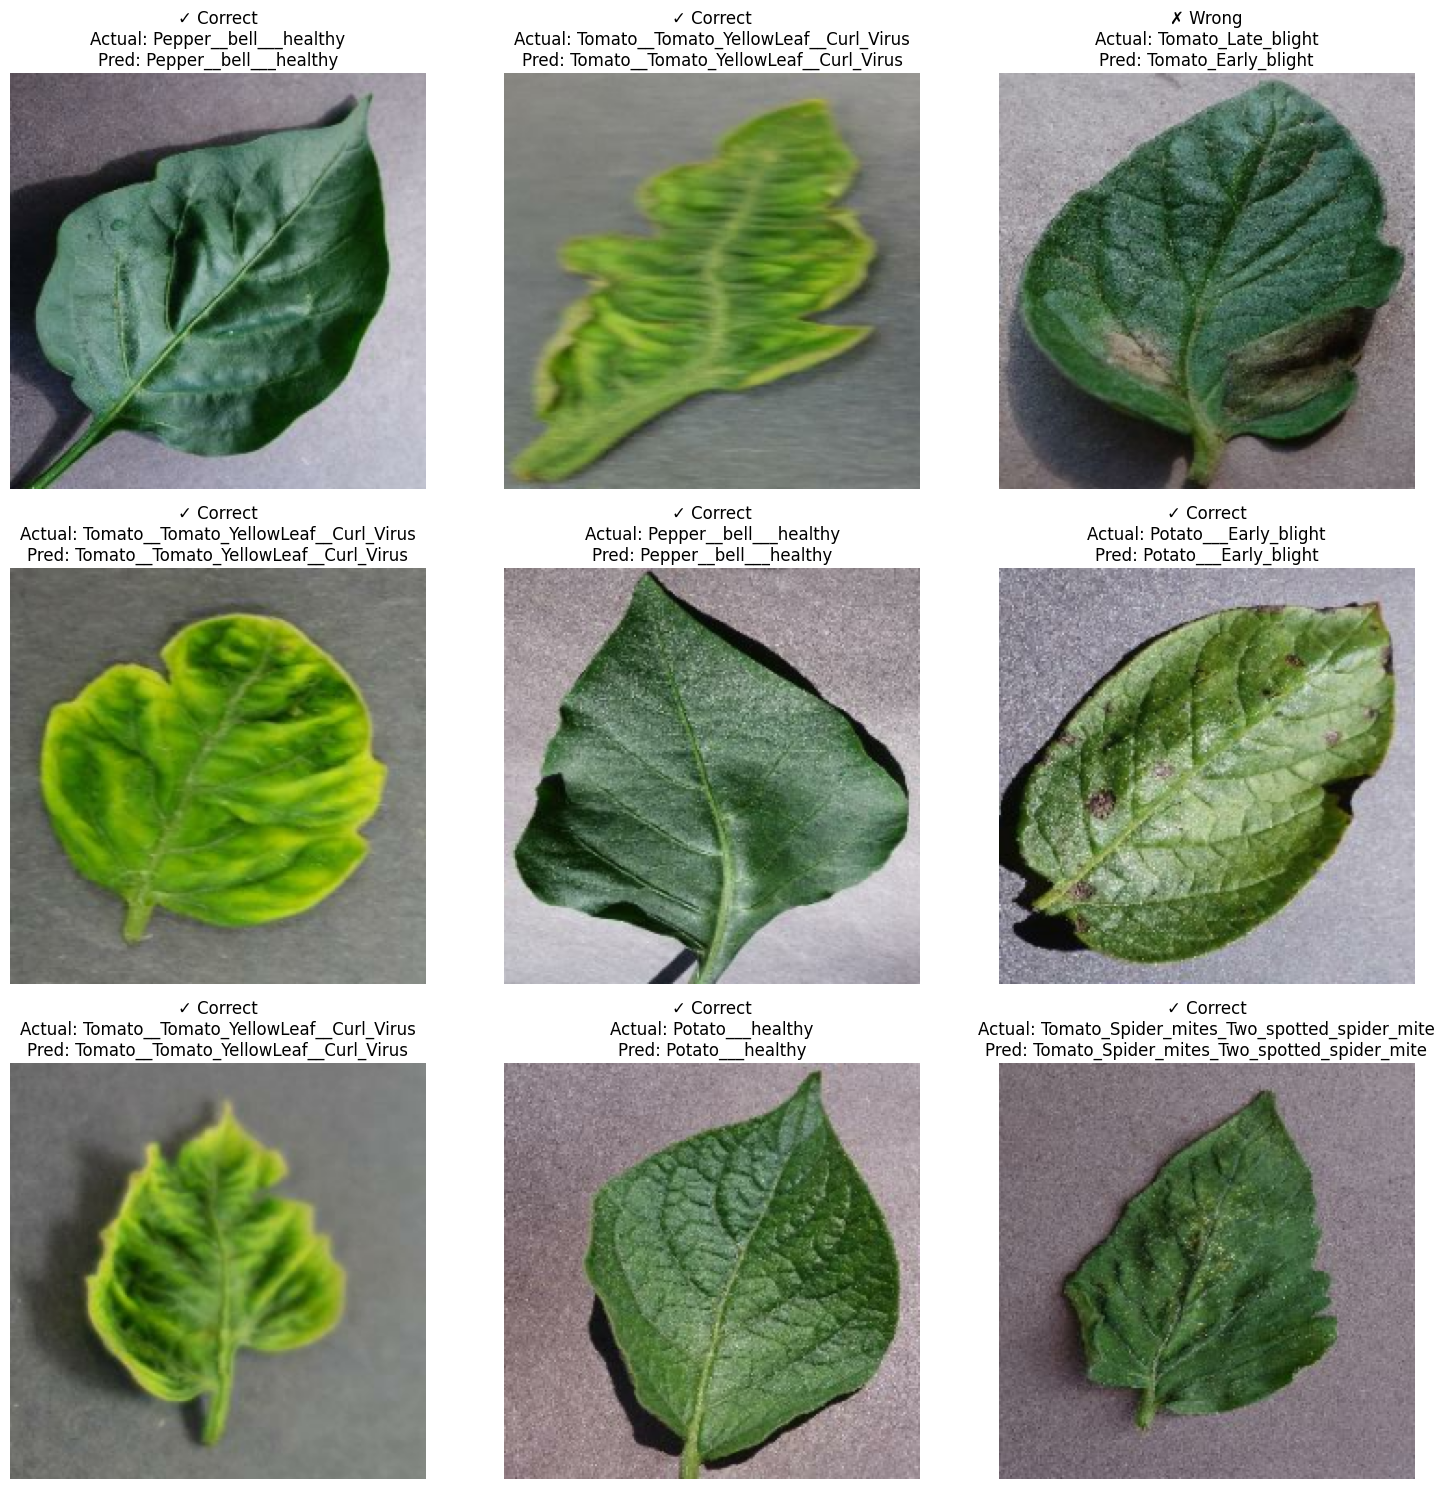

In [ ]:
for images, labels in val_ds.take(1):

    plt.figure(figsize=(15,15))

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        pred = model.predict(
            tf.expand_dims(images[i],0),
            verbose=0
        )

        pred_idx = np.argmax(pred)

        pred_class = class_names[pred_idx]

        actual_class = class_names[
            labels[i].numpy()
        ]

        result = "✓ Correct" if pred_class == actual_class else "✗ Wrong"

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            f"{result}\nActual: {actual_class}\nPred: {pred_class}"
        )

        plt.axis("off")

    plt.tight_layout()

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save(
    "/content/drive/MyDrive/RES_model.keras"
)